# EDA — Dataset de Autenticación de Documentos

**Objetivo:** Explorar visualmente el dataset de muestras sintéticas, entender las distribuciones de píxeles, y validar que las falsificaciones generadas son detectables visualmente.

**Dataset en este notebook:** `data/samples/` — 20 imágenes sintéticas (10 auténticas + 10 falsificadas) generadas por `scripts/generate_samples.py`. Representan el esquema auténtico/falsificado que usaremos en producción con MIDV-500.

**Índice:**
1. Carga del dataset
2. Distribución de clases y dimensiones
3. Estadísticas de píxeles por canal (RGB)
4. Visualización de muestras auténticas vs falsificadas
5. Análisis de diferencias pixel-level entre pares
6. Los 4 tipos de perturbación sintética
7. Distribución de histogramas RGB por clase
8. Conclusiones para el pipeline de preprocesamiento

In [1]:
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from PIL import Image

# Asegurar que el módulo src sea importable
sys.path.insert(0, str(Path.cwd().parent))

from src.data.augmentation import ForgeryConfig, ForgeryType, SyntheticForgeryGenerator

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 11

## 1. Carga del dataset

In [2]:
SAMPLES_DIR = Path.cwd().parent / "data" / "samples"


def load_images(directory: Path) -> list[np.ndarray]:
    paths = sorted(directory.glob("*.png"))
    return [np.array(Image.open(p).convert("RGB")) for p in paths]


authentic = load_images(SAMPLES_DIR / "authentic")
forged = load_images(SAMPLES_DIR / "forged")

print(f"Imágenes auténticas : {len(authentic)}")
print(f"Imágenes falsificadas: {len(forged)}")
print(f"Shape de muestra    : {authentic[0].shape}  dtype={authentic[0].dtype}")

Imágenes auténticas : 10
Imágenes falsificadas: 10
Shape de muestra    : (224, 224, 3)  dtype=uint8


## 2. Distribución de clases y dimensiones

Distribución de dimensiones:
  Alturas únicas : [224]
  Anchos únicos  : [224]
  Canales únicos : [3]


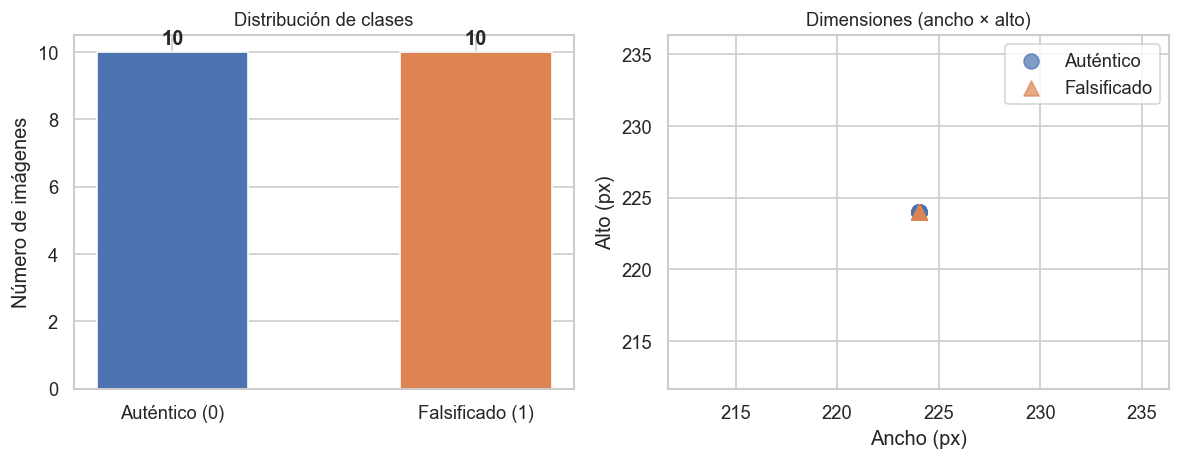


Nota: Dataset balanceado 50/50. En producción con MIDV-500 se espera ratio configurable.


In [3]:
all_images = authentic + forged
labels = [0] * len(authentic) + [1] * len(forged)  # 0=auténtico, 1=falsificado

shapes = [img.shape for img in all_images]
heights = [s[0] for s in shapes]
widths = [s[1] for s in shapes]
channels = [s[2] for s in shapes]

print("Distribución de dimensiones:")
print(f"  Alturas únicas : {sorted(set(heights))}")
print(f"  Anchos únicos  : {sorted(set(widths))}")
print(f"  Canales únicos : {sorted(set(channels))}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Distribución de clases
axes[0].bar(
    ["Auténtico (0)", "Falsificado (1)"],
    [len(authentic), len(forged)],
    color=["#4c72b0", "#dd8452"],
    width=0.5,
    edgecolor="white",
)
axes[0].set_title("Distribución de clases")
axes[0].set_ylabel("Número de imágenes")
for bar, count in zip(axes[0].patches, [len(authentic), len(forged)]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        str(count),
        ha="center",
        va="bottom",
        fontweight="bold",
    )

# Distribución de dimensiones
axes[1].scatter(
    widths[: len(authentic)],
    heights[: len(authentic)],
    c="#4c72b0",
    label="Auténtico",
    s=80,
    alpha=0.7,
)
axes[1].scatter(
    widths[len(authentic) :],
    heights[len(authentic) :],
    c="#dd8452",
    label="Falsificado",
    s=80,
    marker="^",
    alpha=0.7,
)
axes[1].set_title("Dimensiones (ancho × alto)")
axes[1].set_xlabel("Ancho (px)")
axes[1].set_ylabel("Alto (px)")
axes[1].legend()

plt.tight_layout()
plt.savefig("../reports/figures/01_class_distribution.png", dpi=120, bbox_inches="tight")
plt.show()
print("\nNota: Dataset balanceado 50/50. En producción con MIDV-500 se espera ratio configurable.")

## 3. Estadísticas de píxeles por canal (RGB)

In [4]:
def pixel_stats(images: list[np.ndarray]) -> dict:
    stack = np.stack(images)  # (N, H, W, 3)
    return {
        "mean": stack.mean(axis=(0, 1, 2)),
        "std": stack.std(axis=(0, 1, 2)),
        "min": stack.min(axis=(0, 1, 2)),
        "max": stack.max(axis=(0, 1, 2)),
        "p5": np.percentile(stack, 5, axis=(0, 1, 2)),
        "p95": np.percentile(stack, 95, axis=(0, 1, 2)),
    }


stats_auth = pixel_stats(authentic)
stats_forg = pixel_stats(forged)

channels_names = ["R", "G", "B"]
print(f"{'Estadística':<12} {'Auténtico R/G/B':>30}  {'Falsificado R/G/B':>30}")
print("-" * 80)
for stat in ["mean", "std", "min", "max", "p5", "p95"]:
    a = stats_auth[stat]
    f = stats_forg[stat]
    a_str = f"{a[0]:6.1f} / {a[1]:6.1f} / {a[2]:6.1f}"
    f_str = f"{f[0]:6.1f} / {f[1]:6.1f} / {f[2]:6.1f}"
    print(f"{stat:<12} {a_str:>30}  {f_str:>30}")

Estadística                 Auténtico R/G/B               Falsificado R/G/B
--------------------------------------------------------------------------------
mean                222.5 /  224.9 /  227.0         224.1 /  218.3 /  221.3
std                  54.4 /   55.2 /   45.6          55.2 /   58.6 /   49.1
min                   0.0 /    7.0 /   41.0           0.0 /    0.0 /    0.0
max                 251.0 /  254.0 /  255.0         255.0 /  255.0 /  255.0
p5                   63.0 /   63.0 /   86.0          67.0 /   56.0 /   77.0
p95                 251.0 /  254.0 /  255.0         252.0 /  255.0 /  255.0


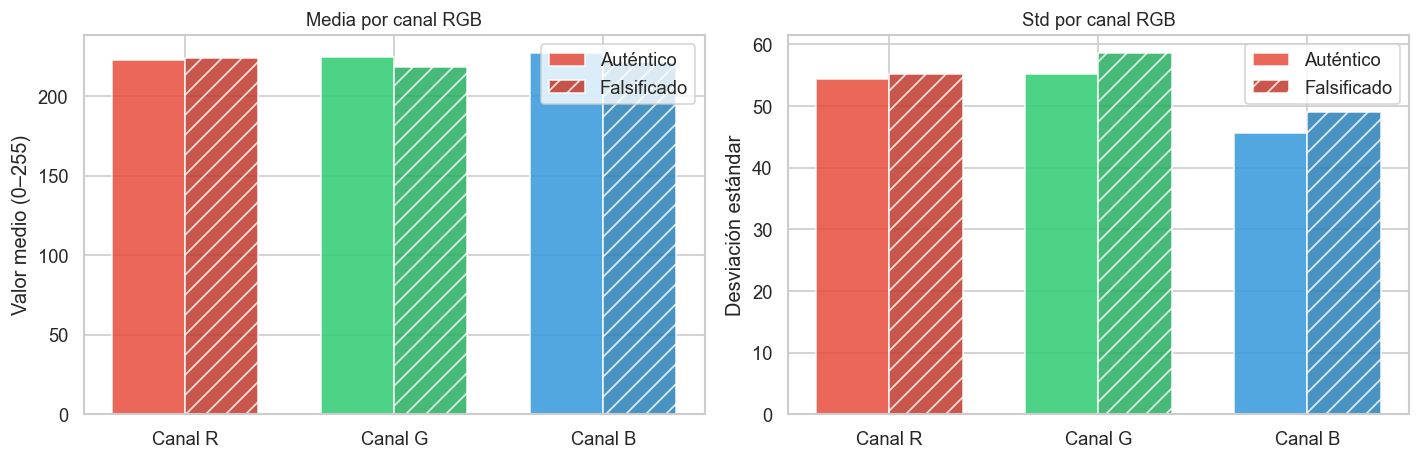

In [5]:
# Comparación visual de medias por canal
x = np.arange(3)
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(
    x - width / 2,
    stats_auth["mean"],
    width,
    label="Auténtico",
    color=["#e74c3c", "#2ecc71", "#3498db"],
    alpha=0.85,
    edgecolor="white",
)
axes[0].bar(
    x + width / 2,
    stats_forg["mean"],
    width,
    label="Falsificado",
    color=["#c0392b", "#27ae60", "#2980b9"],
    alpha=0.85,
    edgecolor="white",
    hatch="//",
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(["Canal R", "Canal G", "Canal B"])
axes[0].set_ylabel("Valor medio (0–255)")
axes[0].set_title("Media por canal RGB")
axes[0].legend()

axes[1].bar(
    x - width / 2,
    stats_auth["std"],
    width,
    label="Auténtico",
    color=["#e74c3c", "#2ecc71", "#3498db"],
    alpha=0.85,
    edgecolor="white",
)
axes[1].bar(
    x + width / 2,
    stats_forg["std"],
    width,
    label="Falsificado",
    color=["#c0392b", "#27ae60", "#2980b9"],
    alpha=0.85,
    edgecolor="white",
    hatch="//",
)
axes[1].set_xticks(x)
axes[1].set_xticklabels(["Canal R", "Canal G", "Canal B"])
axes[1].set_ylabel("Desviación estándar")
axes[1].set_title("Std por canal RGB")
axes[1].legend()

plt.tight_layout()
plt.savefig("../reports/figures/01_pixel_stats.png", dpi=120, bbox_inches="tight")
plt.show()

## 4. Visualización de muestras auténticas vs falsificadas

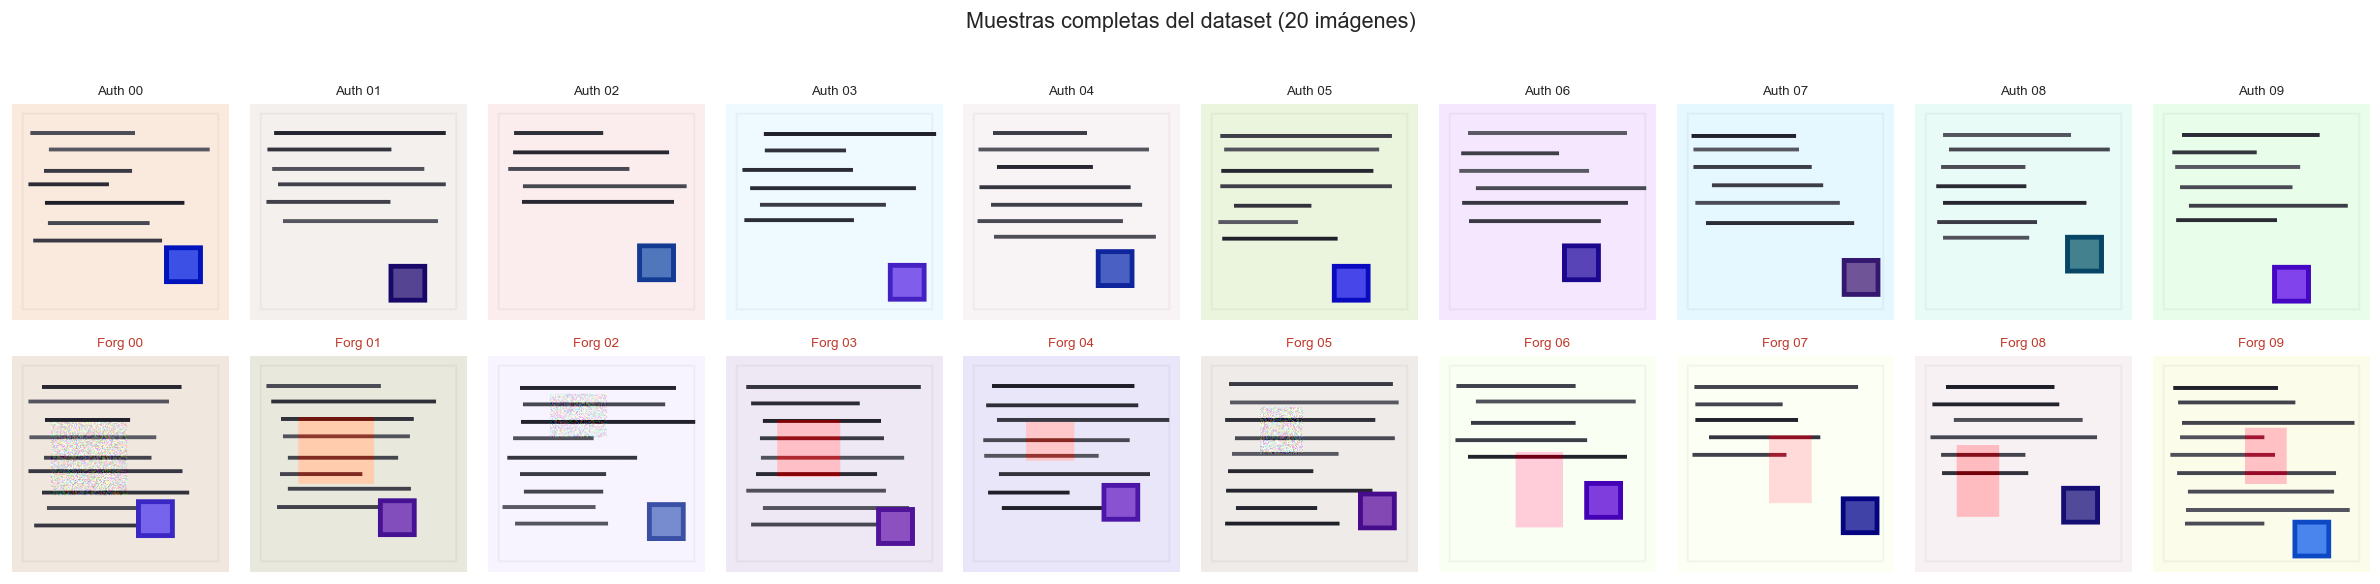

In [6]:
fig, axes = plt.subplots(2, 10, figsize=(20, 5))

for i, img in enumerate(authentic):
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"Auth {i:02d}", fontsize=8)
    axes[0, i].axis("off")

for i, img in enumerate(forged):
    axes[1, i].imshow(img)
    axes[1, i].set_title(f"Forg {i:02d}", fontsize=8, color="#c0392b")
    axes[1, i].axis("off")

# Labels de fila
axes[0, 0].set_ylabel("Auténtico", fontsize=11, rotation=90, labelpad=5)
axes[1, 0].set_ylabel("Falsificado", fontsize=11, rotation=90, color="#c0392b", labelpad=5)

plt.suptitle("Muestras completas del dataset (20 imágenes)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("../reports/figures/01_sample_grid.png", dpi=120, bbox_inches="tight")
plt.show()

## 5. Análisis de diferencias pixel-level entre pares

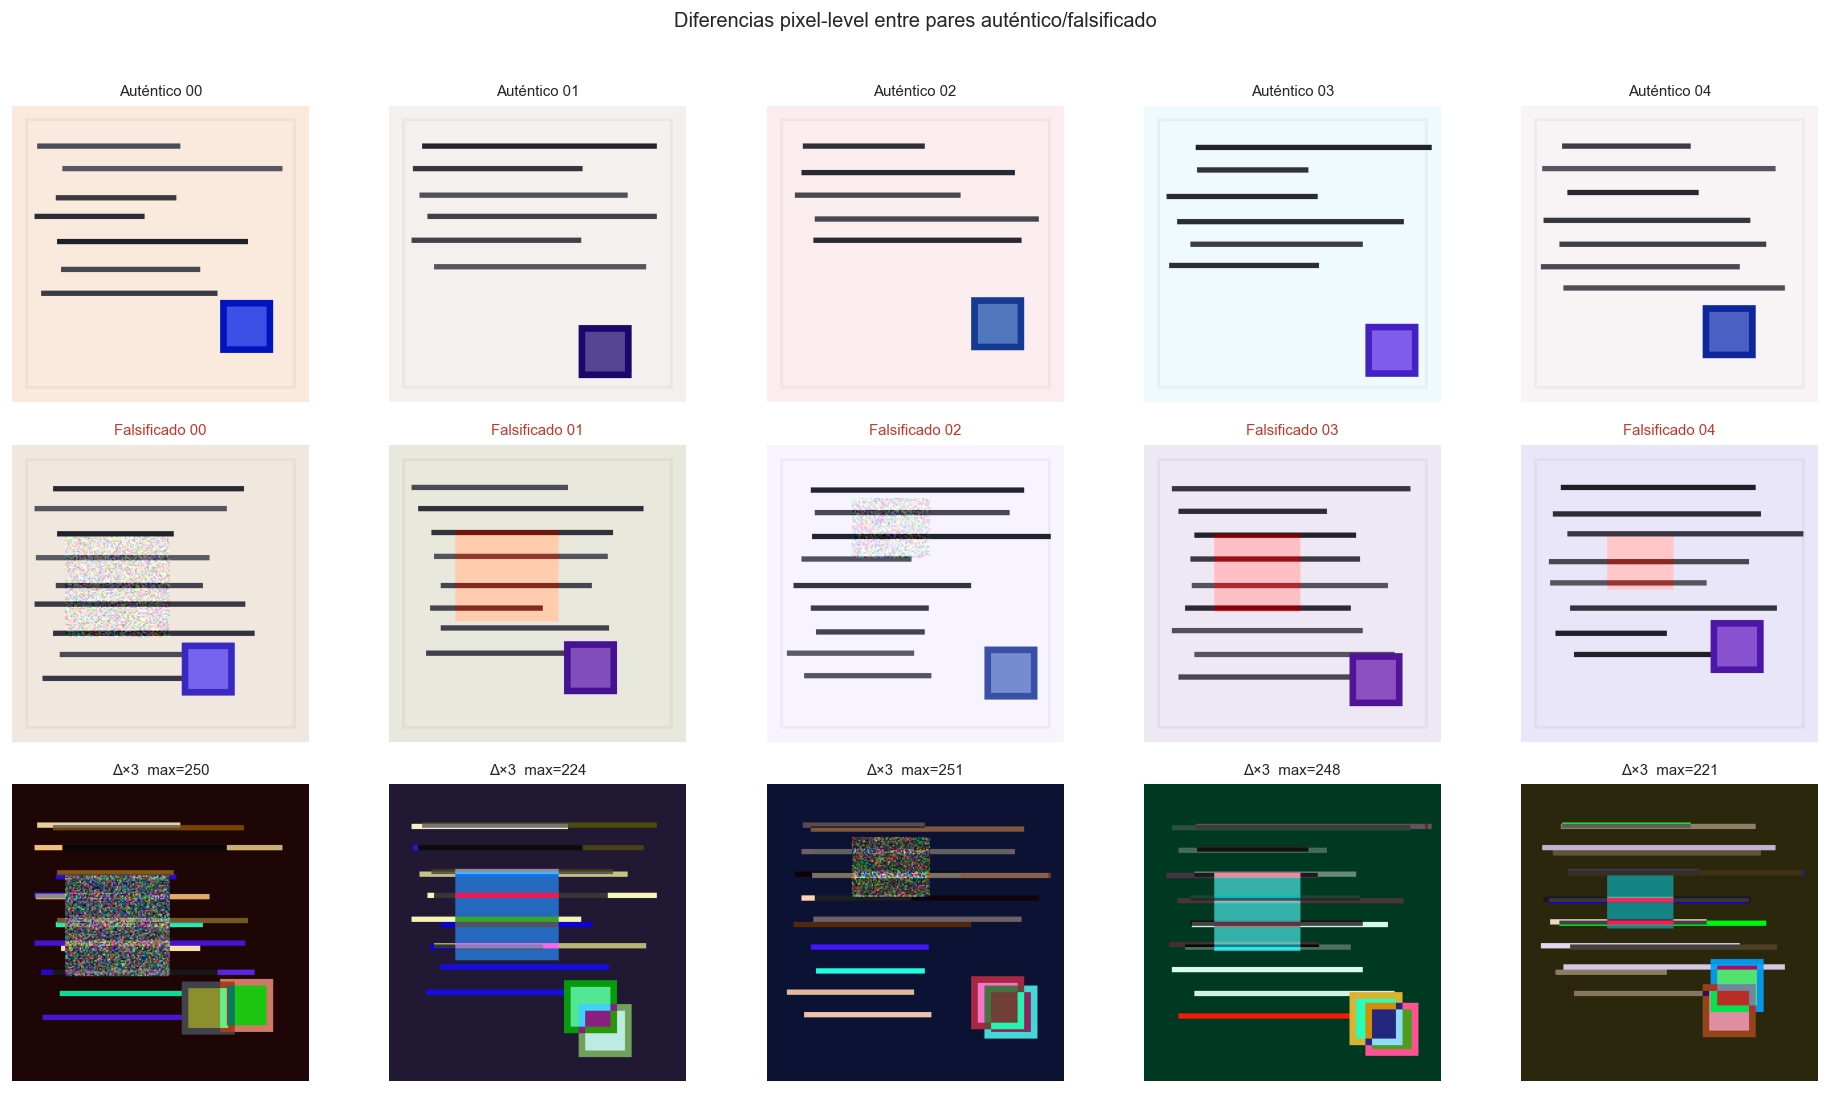

Estadísticas de diferencia absoluta por par:
  Media de diferencias: 29.61
  Max de diferencias  : 242.30
  % píxeles modificados (diff > 5): 73.0%


In [7]:
# Tomar 5 pares (auth[i], forged[i]) y visualizar la diferencia absoluta
n_pairs = 5
fig, axes = plt.subplots(3, n_pairs, figsize=(16, 9))

for i in range(n_pairs):
    diff = np.abs(authentic[i].astype(np.int16) - forged[i].astype(np.int16)).astype(np.uint8)
    diff_enhanced = np.clip(diff * 3, 0, 255).astype(np.uint8)  # amplificar para visibilidad

    axes[0, i].imshow(authentic[i])
    axes[0, i].set_title(f"Auténtico {i:02d}", fontsize=9)
    axes[0, i].axis("off")

    axes[1, i].imshow(forged[i])
    axes[1, i].set_title(f"Falsificado {i:02d}", fontsize=9, color="#c0392b")
    axes[1, i].axis("off")

    im = axes[2, i].imshow(diff_enhanced, cmap="hot")
    axes[2, i].set_title(f"Δ×3  max={diff.max()}", fontsize=9)
    axes[2, i].axis("off")

axes[0, 0].set_ylabel("Auténtico", fontsize=10, rotation=90)
axes[1, 0].set_ylabel("Falsificado", fontsize=10, rotation=90, color="#c0392b")
axes[2, 0].set_ylabel("Diferencia (×3)", fontsize=10, rotation=90)

plt.suptitle("Diferencias pixel-level entre pares auténtico/falsificado", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("../reports/figures/01_pixel_diff.png", dpi=120, bbox_inches="tight")
plt.show()

# Estadísticas de diferencia
all_diffs = [
    np.abs(authentic[i].astype(np.int16) - forged[i].astype(np.int16))
    for i in range(len(authentic))
]
print("Estadísticas de diferencia absoluta por par:")
print(f"  Media de diferencias: {np.mean([d.mean() for d in all_diffs]):.2f}")
print(f"  Max de diferencias  : {np.mean([d.max() for d in all_diffs]):.2f}")
print(
    f"  % píxeles modificados (diff > 5): {np.mean([np.mean(d > 5) for d in all_diffs]) * 100:.1f}%"
)

## 6. Los 4 tipos de perturbación sintética

Generados con `SyntheticForgeryGenerator` desde `src/data/augmentation.py`. Cada tipo simula un ataque de falsificación real:

| Tipo | Simula |
|------|--------|
| `text_blur` | Texto alterado / sobreescrito con blur localizado |
| `color_shift` | Sello falsificado (cambio de tono HSV en región circular) |
| `splicing` | Copia-pega de región de otro documento |
| `hologram_noise` | Holograma de seguridad alterado (ruido Gaussiano localizado) |

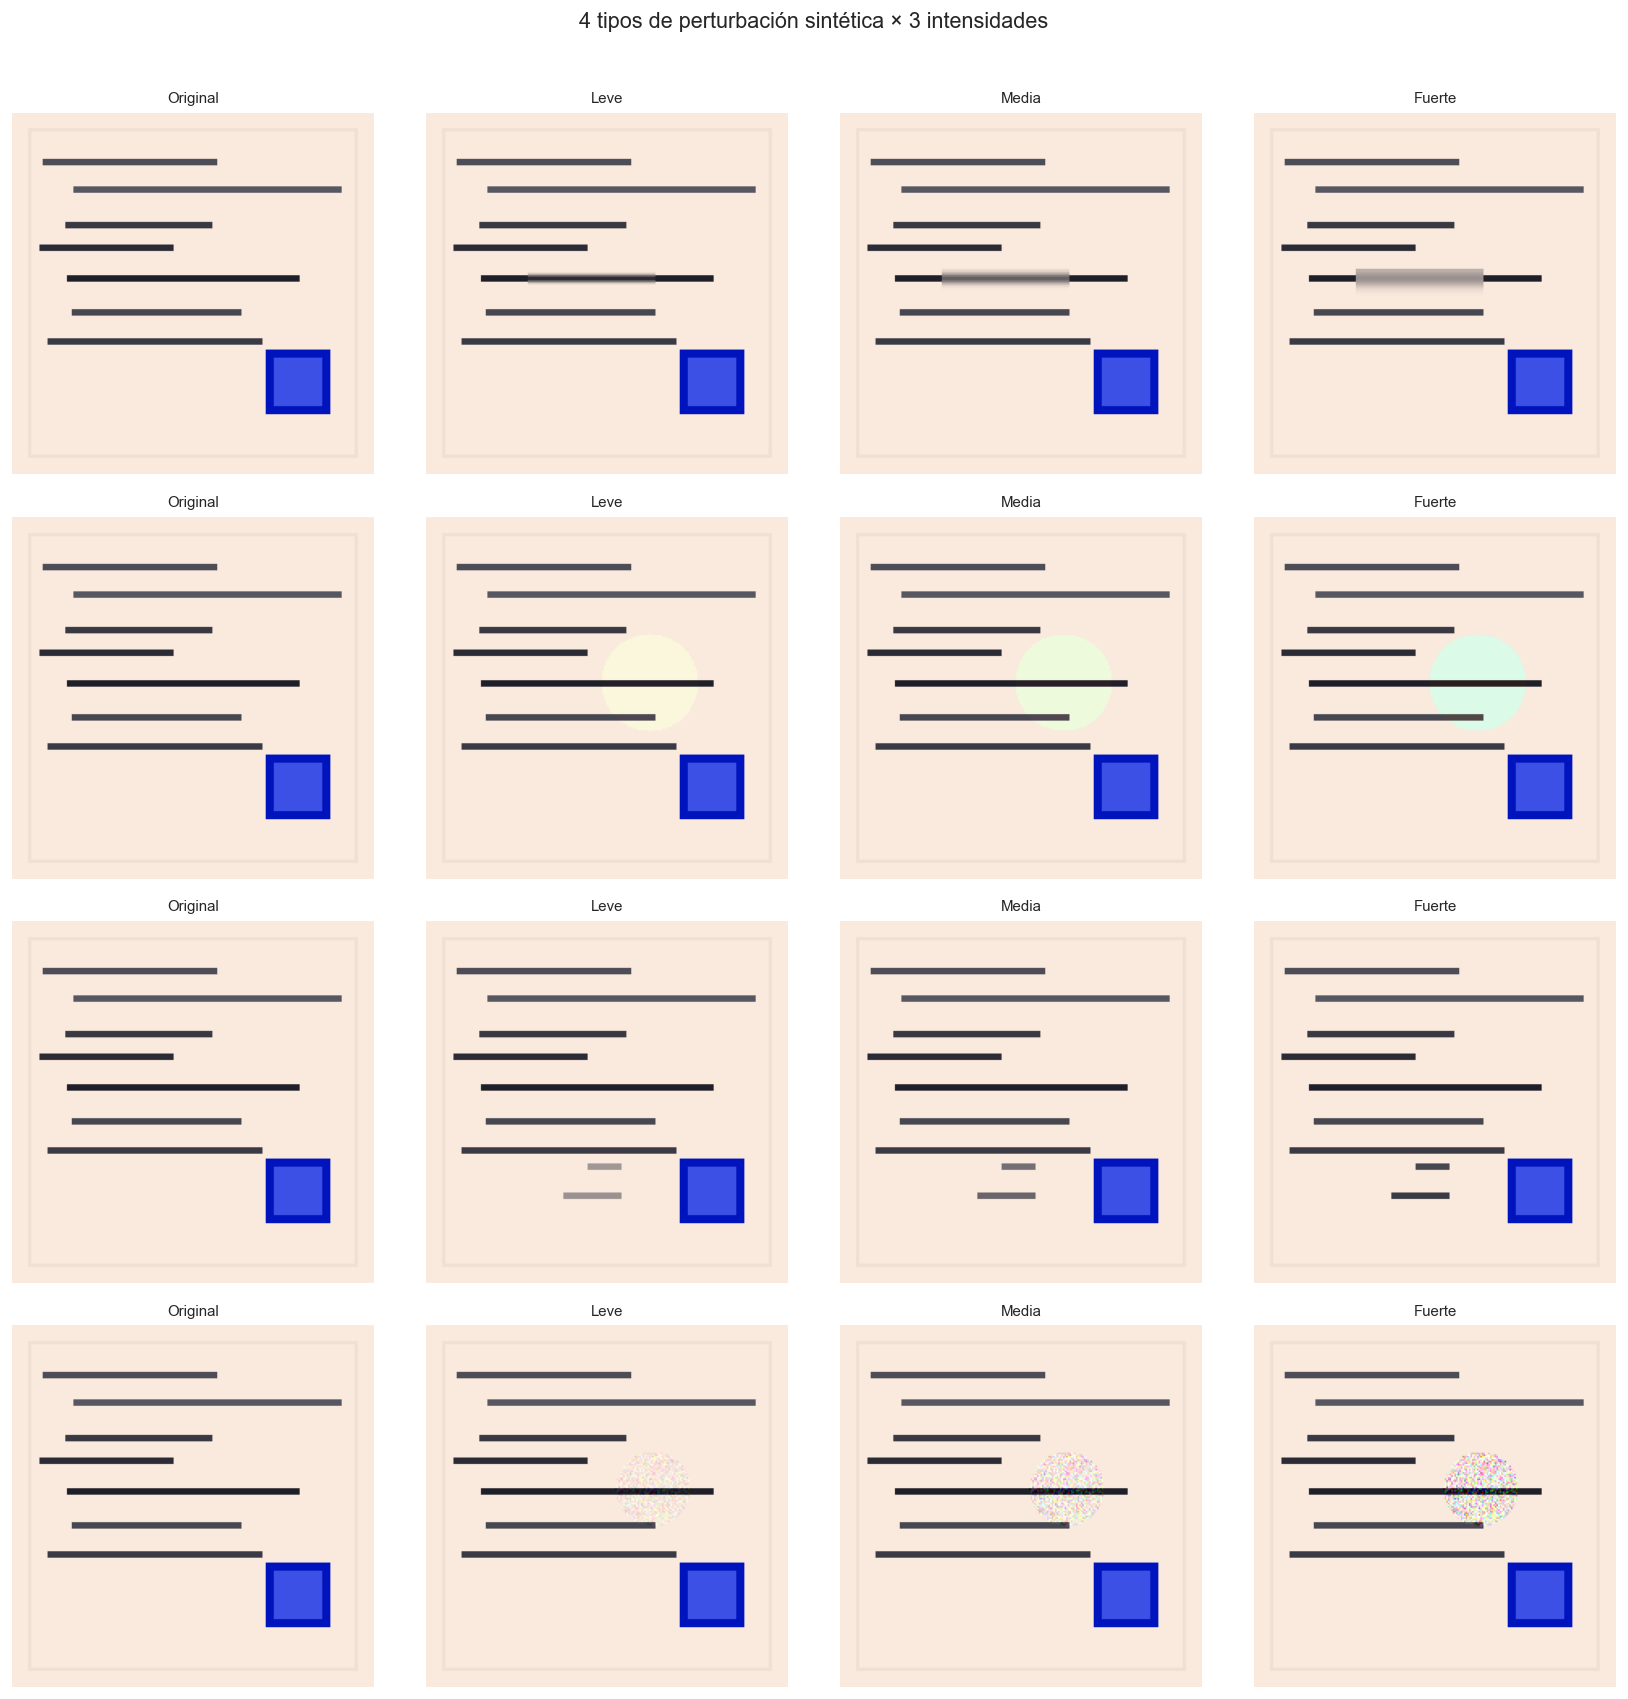

In [8]:
gen = SyntheticForgeryGenerator(seed=42)
base_img = authentic[0]  # imagen base para todas las perturbaciones

forgery_types = [
    ForgeryType.TEXT_BLUR,
    ForgeryType.COLOR_SHIFT,
    ForgeryType.SPLICING,
    ForgeryType.HOLOGRAM_NOISE,
]
intensities = ["mild", "medium", "strong"]
intensity_labels = {"mild": "Leve", "medium": "Media", "strong": "Fuerte"}
type_labels = {
    ForgeryType.TEXT_BLUR: "Text Blur",
    ForgeryType.COLOR_SHIFT: "Color Shift",
    ForgeryType.SPLICING: "Splicing",
    ForgeryType.HOLOGRAM_NOISE: "Hologram Noise",
}

fig, axes = plt.subplots(4, 4, figsize=(14, 14))

for row, ftype in enumerate(forgery_types):
    # Columna 0: imagen original
    axes[row, 0].imshow(base_img)
    axes[row, 0].set_title("Original", fontsize=9)
    axes[row, 0].axis("off")
    axes[row, 0].set_ylabel(type_labels[ftype], fontsize=10, rotation=90, labelpad=50)

    # Columnas 1-3: intensidades
    for col, intensity in enumerate(intensities):
        config = ForgeryConfig(forgery_type=ftype, intensity=intensity, seed=42)
        forged_img = gen.apply(base_img, config)
        axes[row, col + 1].imshow(forged_img)
        axes[row, col + 1].set_title(intensity_labels[intensity], fontsize=9)
        axes[row, col + 1].axis("off")

plt.suptitle("4 tipos de perturbación sintética × 3 intensidades", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("../reports/figures/01_forgery_types.png", dpi=120, bbox_inches="tight")
plt.show()

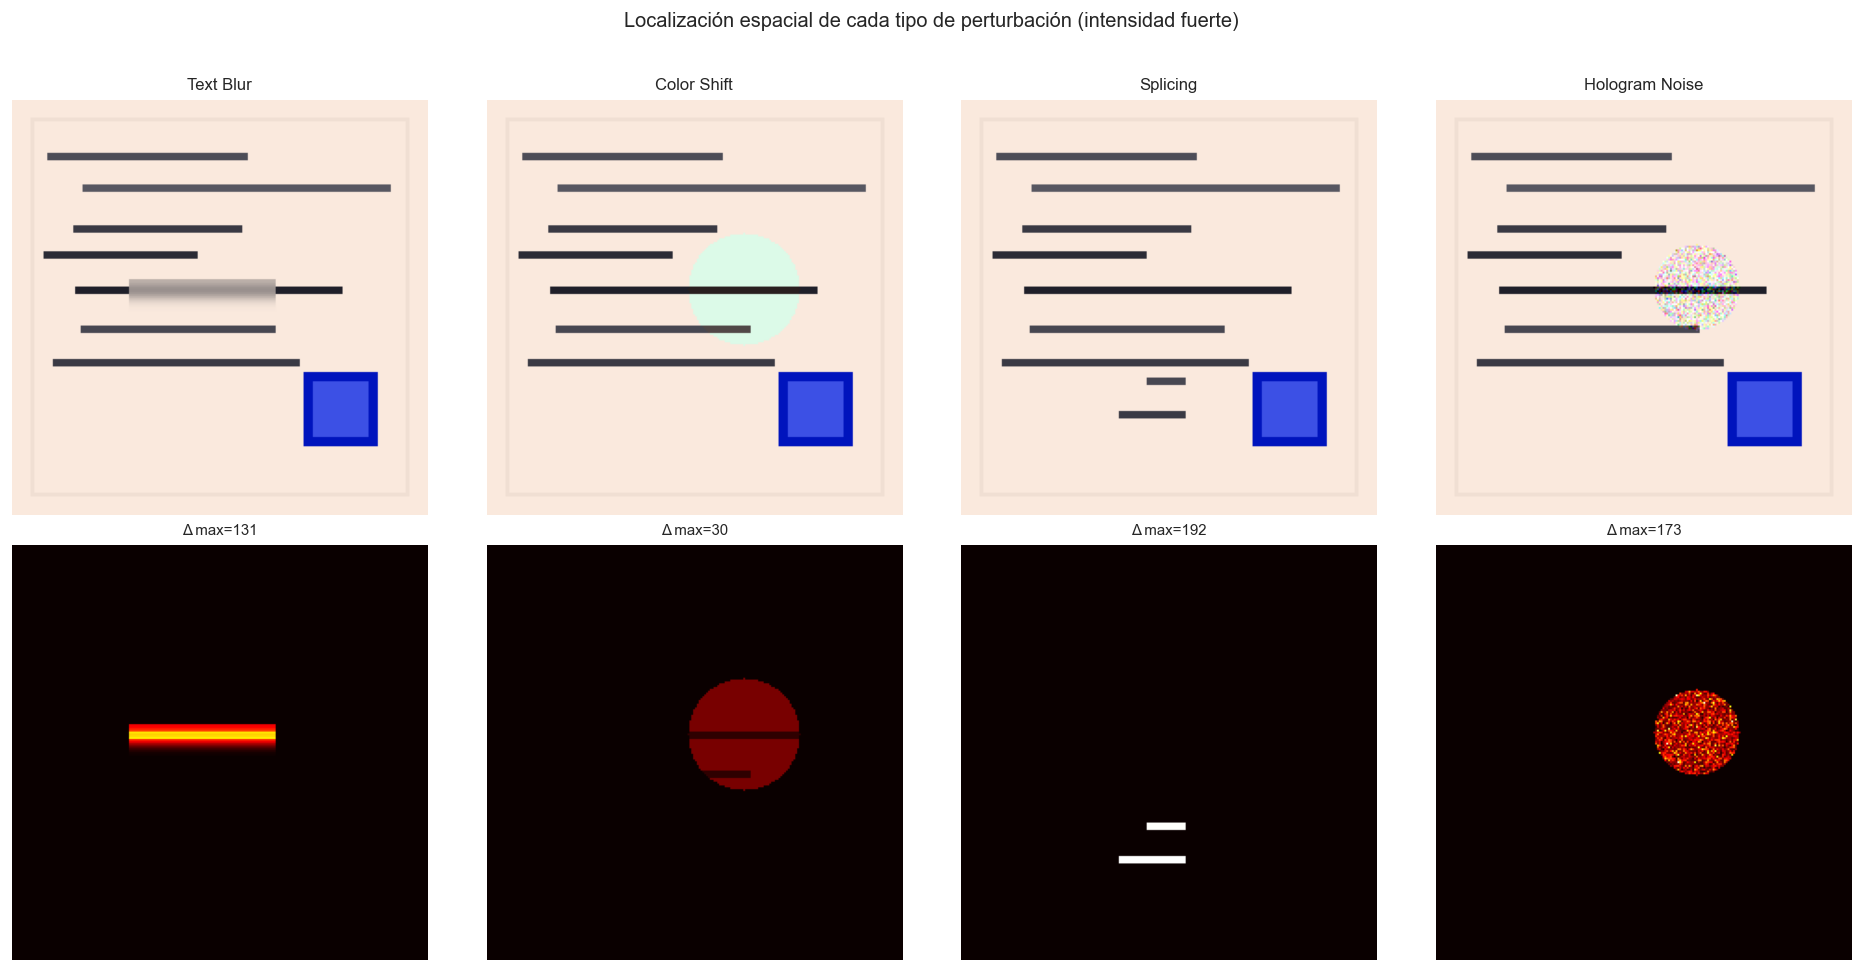

In [9]:
# Mapas de diferencia por tipo de perturbación (intensidad=strong)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for col, ftype in enumerate(forgery_types):
    config = ForgeryConfig(forgery_type=ftype, intensity="strong", seed=42)
    forged_img = gen.apply(base_img, config)
    diff = np.abs(base_img.astype(np.int16) - forged_img.astype(np.int16)).astype(np.uint8)

    axes[0, col].imshow(forged_img)
    axes[0, col].set_title(type_labels[ftype], fontsize=10)
    axes[0, col].axis("off")

    im = axes[1, col].imshow(diff.max(axis=2), cmap="hot", vmin=0, vmax=180)
    axes[1, col].set_title(f"Δ max={diff.max()}", fontsize=9)
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("Imagen falsificada", fontsize=10, rotation=90)
axes[1, 0].set_ylabel("Mapa de diferencia", fontsize=10, rotation=90)

plt.suptitle(
    "Localización espacial de cada tipo de perturbación (intensidad fuerte)", fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig("../reports/figures/01_forgery_diff_maps.png", dpi=120, bbox_inches="tight")
plt.show()

## 7. Distribución de histogramas RGB por clase

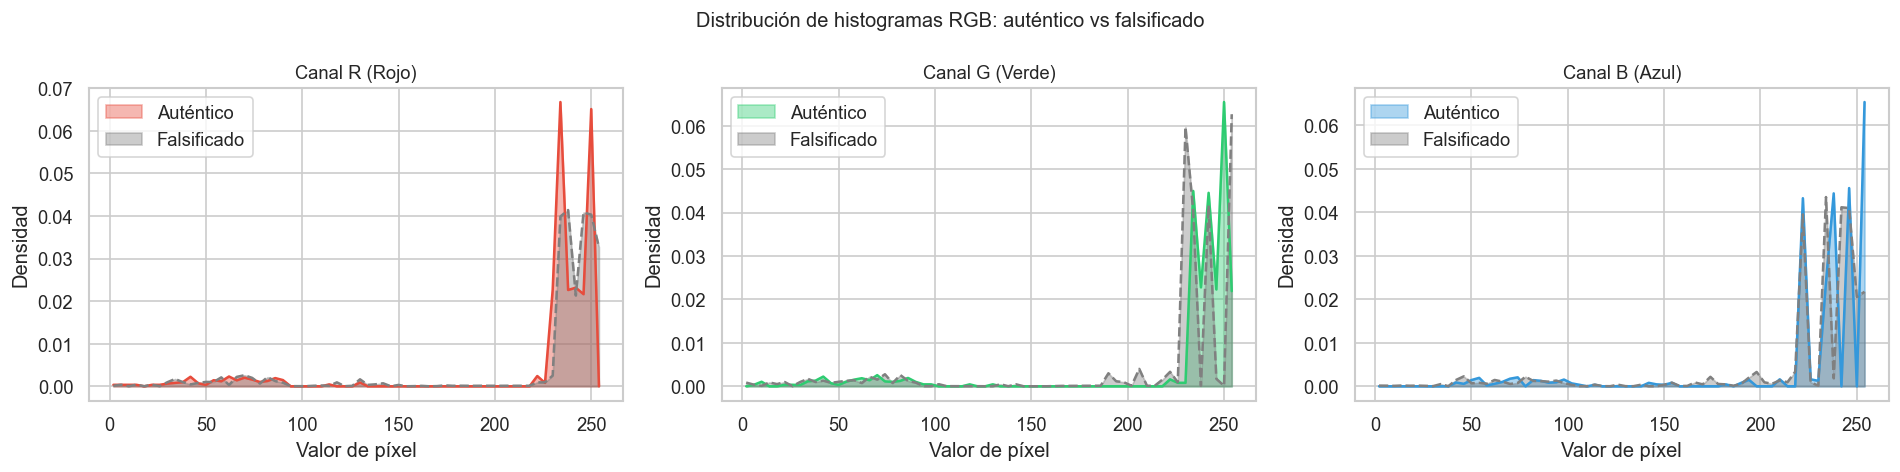

In [10]:
def compute_histogram(images: list[np.ndarray], bins: int = 64) -> np.ndarray:
    """Promedio de histogramas normalizados sobre todas las imágenes."""
    histograms = []
    for img in images:
        hist_channels = []
        for c in range(3):
            h, _ = np.histogram(img[:, :, c], bins=bins, range=(0, 256), density=True)
            hist_channels.append(h)
        histograms.append(hist_channels)
    return np.mean(histograms, axis=0)  # (3, bins)


hist_auth = compute_histogram(authentic)
hist_forg = compute_histogram(forged)

bin_edges = np.linspace(0, 256, 65)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

channel_colors = [
    ("#e74c3c", "Canal R (Rojo)"),
    ("#2ecc71", "Canal G (Verde)"),
    ("#3498db", "Canal B (Azul)"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for c, (color, title) in enumerate(channel_colors):
    axes[c].fill_between(bin_centers, hist_auth[c], alpha=0.4, color=color, label="Auténtico")
    axes[c].fill_between(bin_centers, hist_forg[c], alpha=0.4, color="gray", label="Falsificado")
    axes[c].plot(bin_centers, hist_auth[c], color=color, linewidth=1.5)
    axes[c].plot(bin_centers, hist_forg[c], color="gray", linewidth=1.5, linestyle="--")
    axes[c].set_title(title)
    axes[c].set_xlabel("Valor de píxel")
    axes[c].set_ylabel("Densidad")
    axes[c].legend()

plt.suptitle("Distribución de histogramas RGB: auténtico vs falsificado", fontsize=12)
plt.tight_layout()
plt.savefig("../reports/figures/01_histograms.png", dpi=120, bbox_inches="tight")
plt.show()

/var/folders/n4/hklslsrn5t91cccgjf28xl2c0000gn/T/ipykernel_27038/4126203332.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([bright_auth, bright_forg],


Brillo medio — Auténtico: 235.8  |  Falsificado: 231.5
Brillo std  — Auténtico: 47.0  |  Falsificado: 47.9


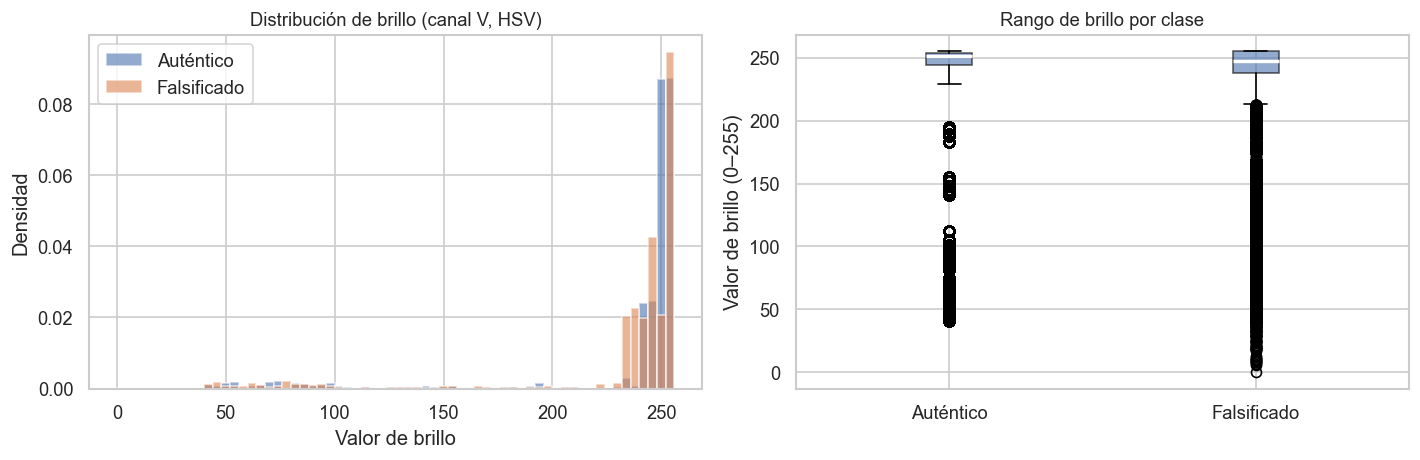

In [11]:
# Distribución de brillo (canal V en HSV) — relevante para CLAHE en preprocesamiento
def brightness_values(images: list[np.ndarray]) -> np.ndarray:
    values = []
    for img in images:
        hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
        values.append(hsv[:, :, 2].flatten())
    return np.concatenate(values)


bright_auth = brightness_values(authentic)
bright_forg = brightness_values(forged)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(
    bright_auth,
    bins=64,
    range=(0, 256),
    density=True,
    alpha=0.6,
    color="#4c72b0",
    label="Auténtico",
)
axes[0].hist(
    bright_forg,
    bins=64,
    range=(0, 256),
    density=True,
    alpha=0.6,
    color="#dd8452",
    label="Falsificado",
)
axes[0].set_title("Distribución de brillo (canal V, HSV)")
axes[0].set_xlabel("Valor de brillo")
axes[0].set_ylabel("Densidad")
axes[0].legend()

# Box plots de brillo por clase
axes[1].boxplot(
    [bright_auth, bright_forg],
    labels=["Auténtico", "Falsificado"],
    patch_artist=True,
    boxprops=dict(facecolor="#4c72b0", alpha=0.6),
    medianprops=dict(color="white", linewidth=2),
)
axes[1].set_title("Rango de brillo por clase")
axes[1].set_ylabel("Valor de brillo (0–255)")

print(
    f"Brillo medio — Auténtico: {bright_auth.mean():.1f}  |  Falsificado: {bright_forg.mean():.1f}"
)
print(f"Brillo std  — Auténtico: {bright_auth.std():.1f}  |  Falsificado: {bright_forg.std():.1f}")

plt.tight_layout()
plt.savefig("../reports/figures/01_brightness.png", dpi=120, bbox_inches="tight")
plt.show()

## 8. Variabilidad dentro de cada clase

Variabilidad media — Auténtico: 0.1048  |  Falsificado: 0.1128


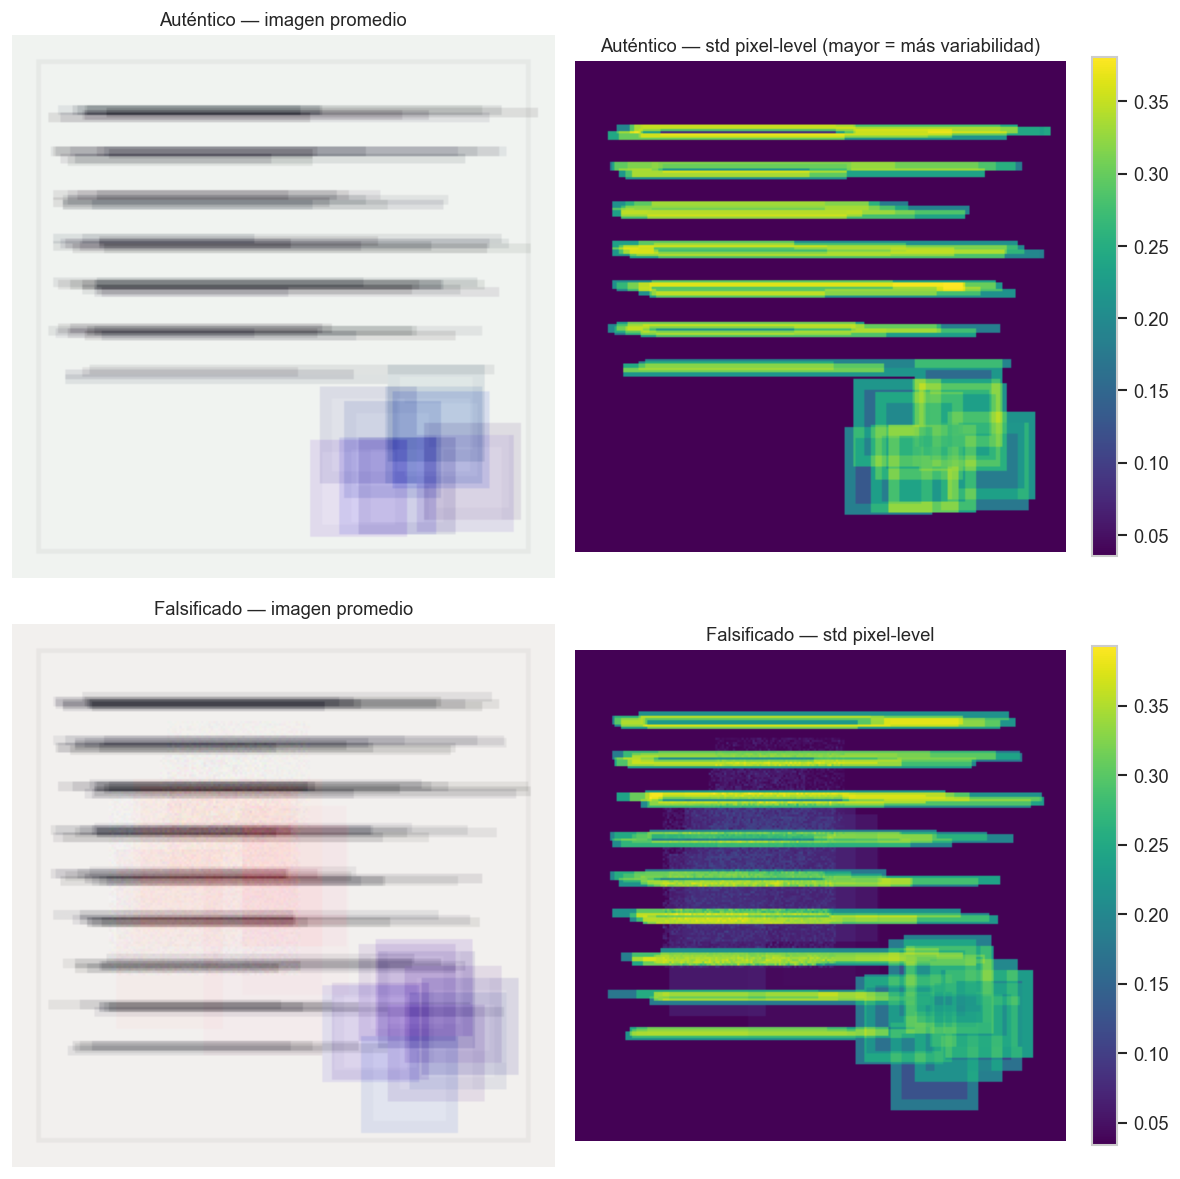

In [12]:
# Imagen promedio y desviación estándar pixel-level por clase
auth_stack = np.stack(authentic).astype(np.float32)
forg_stack = np.stack(forged).astype(np.float32)

auth_mean = auth_stack.mean(axis=0) / 255
auth_std = auth_stack.std(axis=0) / 255
forg_mean = forg_stack.mean(axis=0) / 255
forg_std = forg_stack.std(axis=0) / 255

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

axes[0, 0].imshow(auth_mean)
axes[0, 0].set_title("Auténtico — imagen promedio")
axes[0, 0].axis("off")

im1 = axes[0, 1].imshow(auth_std.mean(axis=2), cmap="viridis")
axes[0, 1].set_title("Auténtico — std pixel-level (mayor = más variabilidad)")
axes[0, 1].axis("off")
plt.colorbar(im1, ax=axes[0, 1], fraction=0.046)

axes[1, 0].imshow(forg_mean)
axes[1, 0].set_title("Falsificado — imagen promedio")
axes[1, 0].axis("off")

im2 = axes[1, 1].imshow(forg_std.mean(axis=2), cmap="viridis")
axes[1, 1].set_title("Falsificado — std pixel-level")
axes[1, 1].axis("off")
plt.colorbar(im2, ax=axes[1, 1], fraction=0.046)

print(
    f"Variabilidad media — Auténtico: {auth_std.mean():.4f}  |  Falsificado: {forg_std.mean():.4f}"
)

plt.tight_layout()
plt.savefig("../reports/figures/01_class_variability.png", dpi=120, bbox_inches="tight")
plt.show()

## 9. Resumen cuantitativo del dataset

In [13]:
print("=" * 60)
print("RESUMEN DEL DATASET")
print("=" * 60)
print(f"Total imágenes        : {len(all_images)}")
print(f"  Auténticas (clase 0): {len(authentic)}")
print(f"  Falsificadas (clase 1): {len(forged)}")
print(f"Ratio de clases       : {len(authentic) / len(forged):.1f}:1")
print()
print(
    f"Resolución uniforme   : {authentic[0].shape[1]}×{authentic[0].shape[0]}px, {authentic[0].shape[2]} canales"
)
print(f"Dtype                 : {authentic[0].dtype}")
print("Rango de valores      : [0, 255]")
print()
print("Estadísticas de píxeles (sobre todas las imágenes):")
all_stack = np.stack(all_images)
print(f"  Media global         : {all_stack.mean():.2f}")
print(f"  Std global           : {all_stack.std():.2f}")
print(f"  Brillo medio (auth)  : {bright_auth.mean():.2f}")
print(f"  Brillo medio (forg)  : {bright_forg.mean():.2f}")
print()
print("Tipos de falsificación presentes en el dataset:")
for ft in ForgeryType:
    print(f"  - {ft.value}")
print()
print("=" * 60)
print("IMPLICACIONES PARA EL PIPELINE (Fase 2)")
print("=" * 60)
print("1. Dimensiones uniformes 224×224 → resize ya aplicado, no se necesita corrección")
print("2. Rango [0,255] → normalizar a [0,1] o ImageNet stats antes del modelo")
print("3. Variabilidad de brillo moderada → CLAHE beneficiará documentos con iluminación variable")
print(
    "4. Perturbaciones localizadas (10-25% del área) → Grad-CAM debería localizarlas con precisión"
)
print("5. Dataset balanceado → no se necesita class weighting inicial")

RESUMEN DEL DATASET
Total imágenes        : 20
  Auténticas (clase 0): 10
  Falsificadas (clase 1): 10
Ratio de clases       : 1.0:1

Resolución uniforme   : 224×224px, 3 canales
Dtype                 : uint8
Rango de valores      : [0, 255]

Estadísticas de píxeles (sobre todas las imágenes):
  Media global         : 223.02
  Std global           : 53.25
  Brillo medio (auth)  : 235.83
  Brillo medio (forg)  : 231.53

Tipos de falsificación presentes en el dataset:
  - text_blur
  - color_shift
  - splicing
  - hologram_noise

IMPLICACIONES PARA EL PIPELINE (Fase 2)
1. Dimensiones uniformes 224×224 → resize ya aplicado, no se necesita corrección
2. Rango [0,255] → normalizar a [0,1] o ImageNet stats antes del modelo
3. Variabilidad de brillo moderada → CLAHE beneficiará documentos con iluminación variable
4. Perturbaciones localizadas (10-25% del área) → Grad-CAM debería localizarlas con precisión
5. Dataset balanceado → no se necesita class weighting inicial


## Conclusiones

**Dataset:**
- 20 imágenes sintéticas 224×224 RGB, balanceadas al 50%
- Las falsificaciones son visualmente distinguibles: las diferencias pixel-level están localizadas en regiones específicas (10-25% del área total)
- Los 4 tipos de perturbación producen firmas espectrales distintas: `color_shift` afecta principalmente el canal R/G, `text_blur` reduce la frecuencia espacial, `hologram_noise` incrementa la std local

**Para Fase 2 (preprocesamiento):**
- CLAHE en canal L (LAB): útil para normalizar variabilidad de iluminación en documentos reales MIDV-500
- Denoising opcional: las muestras sintéticas son limpias; en MIDV-500 habrá ruido de captura real
- Normalización ImageNet: obligatoria antes de EfficientNet-B0

**Para Fase 4 (Grad-CAM):**
- Las perturbaciones son localizadas y compactas → el mapa de activación debería concentrarse en la región alterada
- `color_shift` y `hologram_noise` producen los mayores delta de píxel → más fáciles de detectar visualmente
- `text_blur` puede ser más sutil (solo afecta frecuencias altas) → posiblemente más difícil de detectar